In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# exercise 08.1



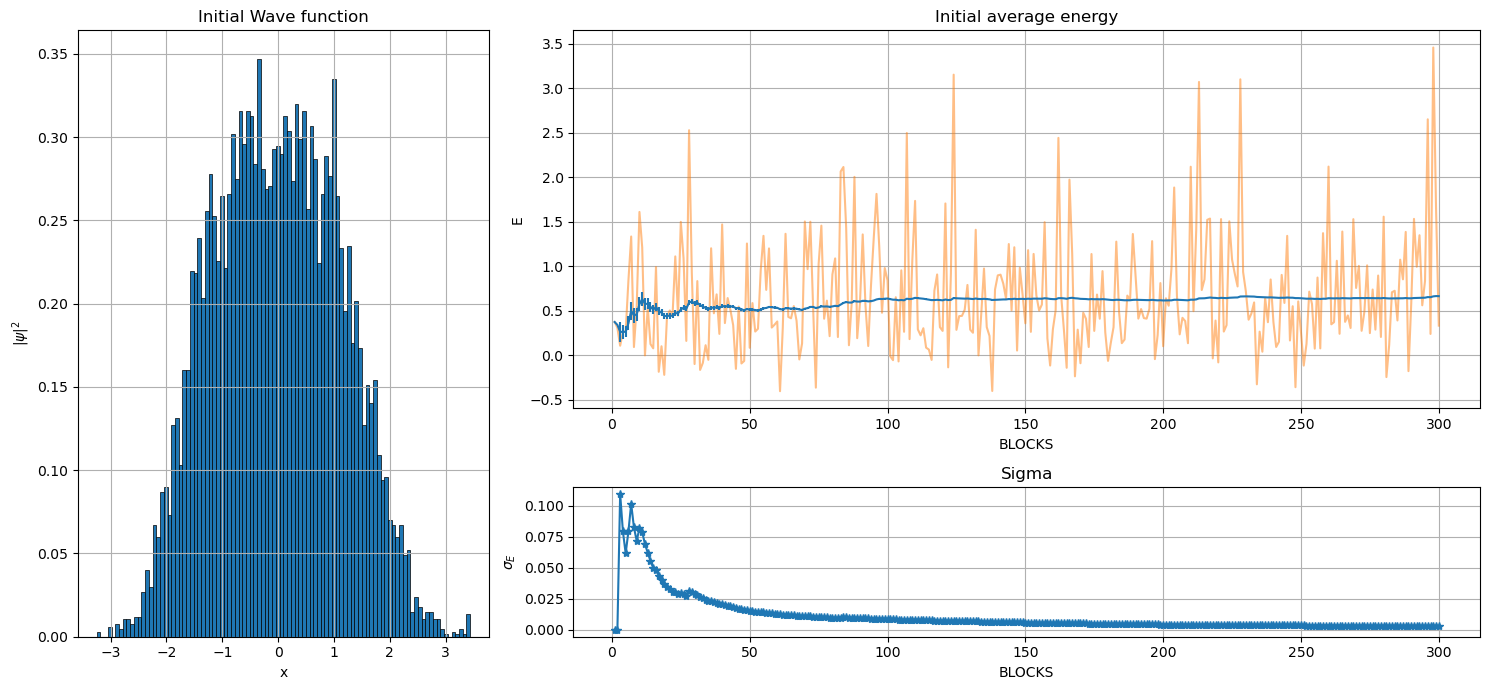

In [11]:
init_wf = pd.read_csv('CODE/OUTPUT/config2/initial_wf.dat', skiprows=1)
en0 = pd.read_csv("CODE/OUTPUT/config2/initial_energy.dat", skiprows=1)


fig = plt.figure(figsize=(15,7))


gs = gridspec.GridSpec(3, 3, figure=fig)

ax = fig.add_subplot(gs[:,0])
ax.set_title('Initial Wave function')
ax.hist(init_wf, bins=100, density=True, linewidth=0.5, edgecolor="black",)

ax.set_xlabel('x')
ax.set_ylabel(r'$|\psi|^2$')
ax.grid()


ax = fig.add_subplot(gs[0:2,1:])
ax.set_title('Initial average energy')
ax.plot(en0['BLOCK'], en0[' ACTUAL_E'], c='C1', label='actual', alpha=0.5)
ax.errorbar(en0['BLOCK'], en0[' E_AVE'], yerr=en0[' ERR'], label='avg')
ax.grid()
# ax.set_ylim([10, 30])
ax.set_xlabel('BLOCKS')
ax.set_ylabel('E')


ax = fig.add_subplot(gs[2,1:])
ax.set_title('Sigma')
ax.plot(en0['BLOCK'], en0[' ERR'], '-*')
ax.grid()
ax.set_xlabel('BLOCKS')
ax.set_ylabel(r'$\sigma_E$')



plt.tight_layout()
plt.show()


## Exercise 08.2

### Structure of the code:

```C++

    System SYS;
    
    SYS.initialize();

    int nst=SYS.get_n_annealing_steps();
    while (!SYS.terminated()) 
    {
        for (int k=0; k<nst; k++) 
        {
            SYS.anneal_move();            
        }
        cout << endl;
        SYS.cooling();    
    }

```

The annealing move is made using a monte carlo sampling to compute the new proposed energy and performing a metropolis algorithm to accept the new parameters using the new energy value.

The `annealing_distribution` to generate the new parameters is choosen in the input file


```C++
void System::anneal_move()
{
    // generate new annealing parameter with initial distribution
    _new_mu=(_rnd.*annealing_distribution)(_mu, distr_width);
    _new_sigma=(_rnd.*annealing_distribution)(_sigma, distr_width);

    //compute new proposal energy
    // use the values in _new_mu & _new_sigma
    _new_energy = compute_energy(new_params=true); 
    

    if(this->anneal_metro())
    {
        // override values of actual mu, sigma & energy
        this->accept_anneal_move();
    }

    _nanneal_attempts+=1;
    
    return;
    
}

```

The `cooling` function must be specified in input (seee [the appendix](###Appendix) for the structure of input file ), the following temperature update law are implemented:

- "STEP" = temperature decrease of a constant (specified from the user) step until a minimum temperature $T_n = T_0-n*step$

- "RATE" = temperature decrease with a user-specified rate until it reach the minimum temperature $T_n = (rate)^n * T_0$

- "STEP_BETA" = beta increase of a constant step (specified from the user) until it reach the maximum value of beta $\beta_n = \beta_0 + n*step$

- "RATE_BETA" = beta increase with a constant factor  until it reach the max beta value  $\beta_n = (rate)^n \beta_0$


### Data 

#### Diagonalization results

Ground state energy:  -0.460465879692715
1st excited state energy:  0.0974247133176097
2nd excited state energy:  1.9717331343930198


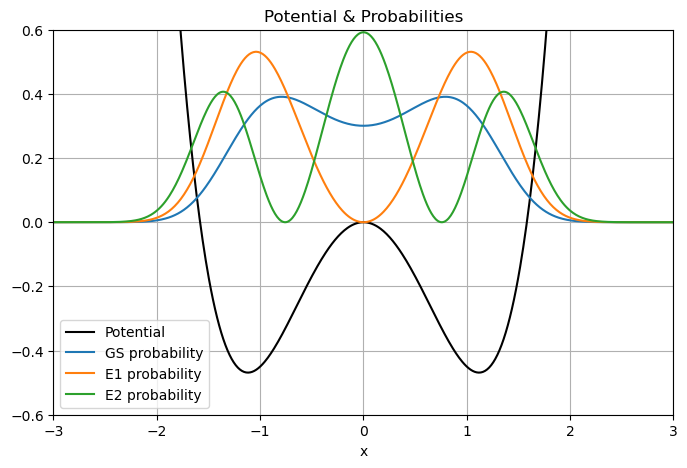

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
plt.figure(figsize=(8,5))
scale = 0.3
plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
plt.plot(x,(psi[0])**2, label='GS probability')
plt.plot(x,(psi[1])**2, label='E1 probability')
plt.plot(x,(psi[2])**2, label='E2 probability')
plt.title("Potential & Probabilities")
plt.xlabel("x")
plt.grid(True)
plt.xlim((-3,3))
plt.ylim((-0.6,0.6))
plt.legend()
plt.show()

#### MC results

In [13]:
df=pd.read_csv('CODE/OUTPUT/config2/optimization.dat',sep=", " )
df['beta']=1./df['TEMP']


/tmp/ipykernel_12655/2028137045.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df=pd.read_csv('CODE/OUTPUT/config2/optimization.dat',sep=", " )


In the following image we can see that along the cooling process (each temperature has a different color) the energy distribution tend to converge at the minimum value of -0.448042


In [14]:
print(df.EN.min())

-0.448042


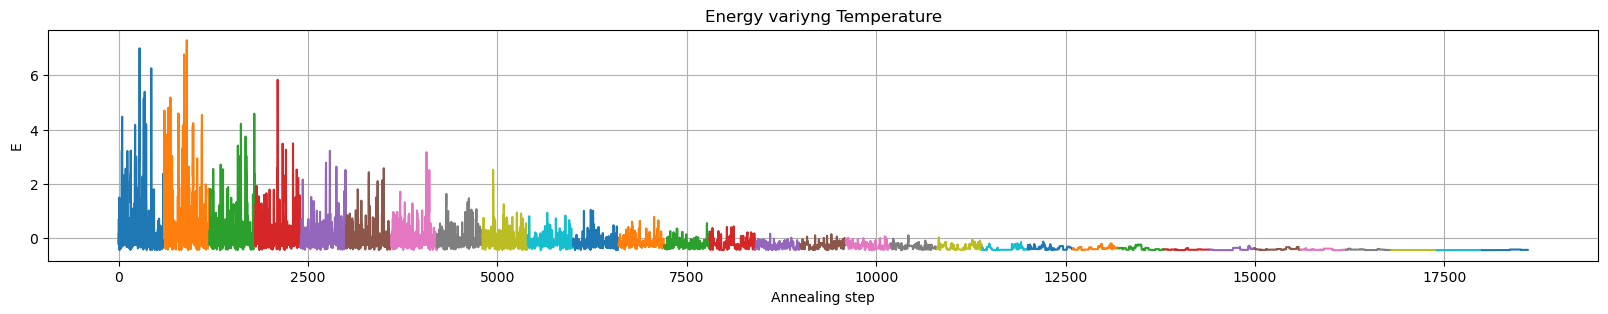

In [15]:
plt.figure(figsize=(20, 3))
for T in df.TEMP.unique():
    plt.plot(df.loc[df.TEMP==T]['EN'], label=f'T={T}')
plt.grid()
plt.xlabel('Annealing step')
plt.ylabel('E')
plt.title('Energy variyng Temperature')
plt.show()

In [16]:
dflast=df.loc[df.STEP==600]
dflast['beta']=1./dflast['TEMP']
dflast.head()

/tmp/ipykernel_12655/4103404036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dflast['beta']=1./dflast['TEMP']


,TEMP,STEP,MU,SIGMA,BLOCK,EN,ERR,beta
599,4.00000,600,0.561883,1.348360,300,0.925466,0.005243,0.250000
1200,2.77778,600,0.375583,-0.770210,300,-0.186023,0.000674,0.360000
1801,2.31481,600,-1.244620,-0.412279,300,0.606369,0.002070,0.432001
2402,1.92901,600,-0.649316,-0.855456,300,-0.283865,0.002687,0.518401
3003,1.60751,600,-0.570585,-0.751387,300,-0.301601,0.002807,0.622080


In the graph below it's shown the last energy value for each Temperature step with the statistical uncertainty computed in the MC evaluation of the energy integral.

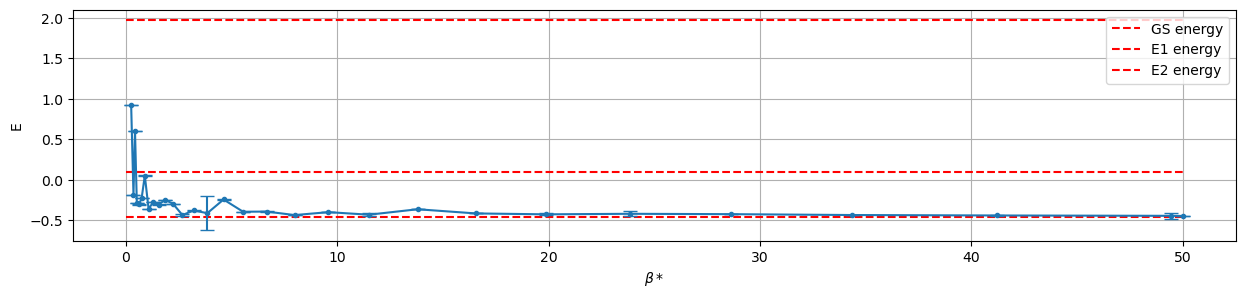

In [17]:
plt.figure(figsize=(15,3))
plt.hlines(E[0], 0, 50, color='r', ls='--', label='GS energy')
plt.hlines(E[1], 0, 50, color='r', ls='--', label='E1 energy')
plt.hlines(E[2], 0, 50, color='r', ls='--', label='E2 energy')
plt.errorbar(dflast.beta, dflast.EN, yerr=dflast['ERR'], capsize=5, marker='o', ms=3)
plt.xlabel(r'$\beta*$')
plt.ylabel('E')
plt.grid()
plt.legend()
plt.show()

below we can see the evolution of the 2 defining parameters $(\sigma, \mu)$ of the annealing wave function  (each dot correspond at a step of the metropolis algorithm on the 2 parameters, so they are not labeled by temperature)

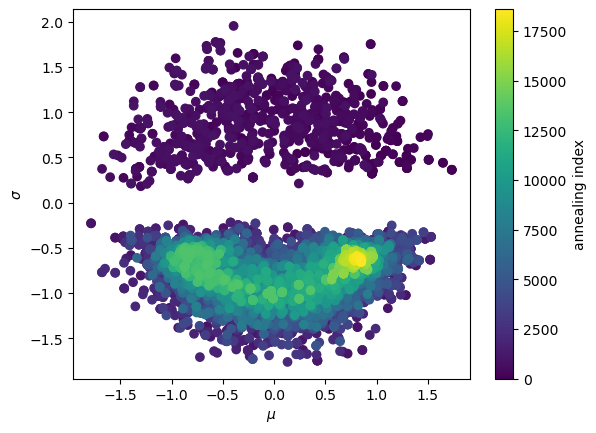

In [18]:

plt.scatter(df['MU'], df['SIGMA'], c=df.index)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')

plt.colorbar(label='annealing index')
plt.show()

mu= 0.778989
sigma =  -0.619258


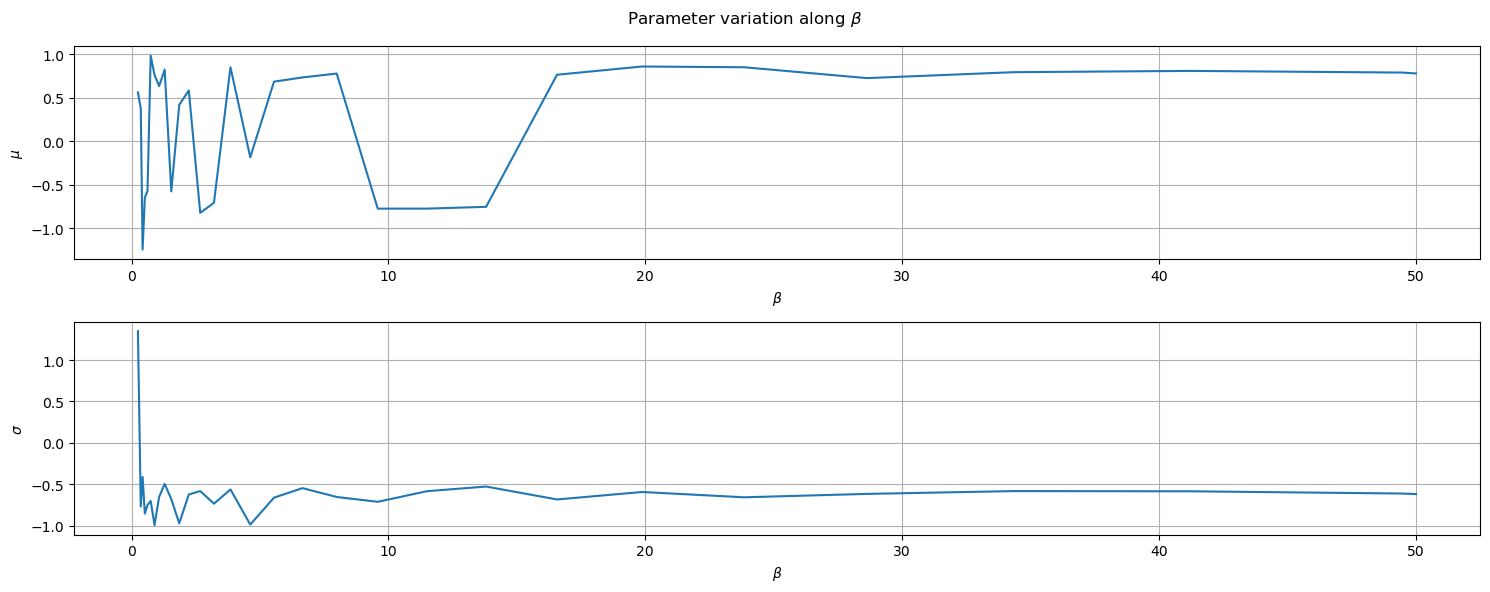

In [19]:
fig, ax = plt.subplots(2,1, figsize=(15,6))
fig.suptitle(r'Parameter variation along $\beta$')
ax[0].plot(dflast.beta, dflast['MU'])
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel(r'$\mu$')
ax[0].grid()
print("mu=",dflast['MU'][dflast.index[-1]])

ax[1].plot(dflast.beta, dflast['SIGMA'])
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel(r'$\sigma$')
ax[1].grid()

print('sigma = ', dflast['SIGMA'][dflast.index[-1]])
plt.tight_layout()

Below are represented all step of optimization on the 2 parameters divided per temperature values with a rolling-window mean of size 500

mu= 0.778989
sigma =  -0.619258


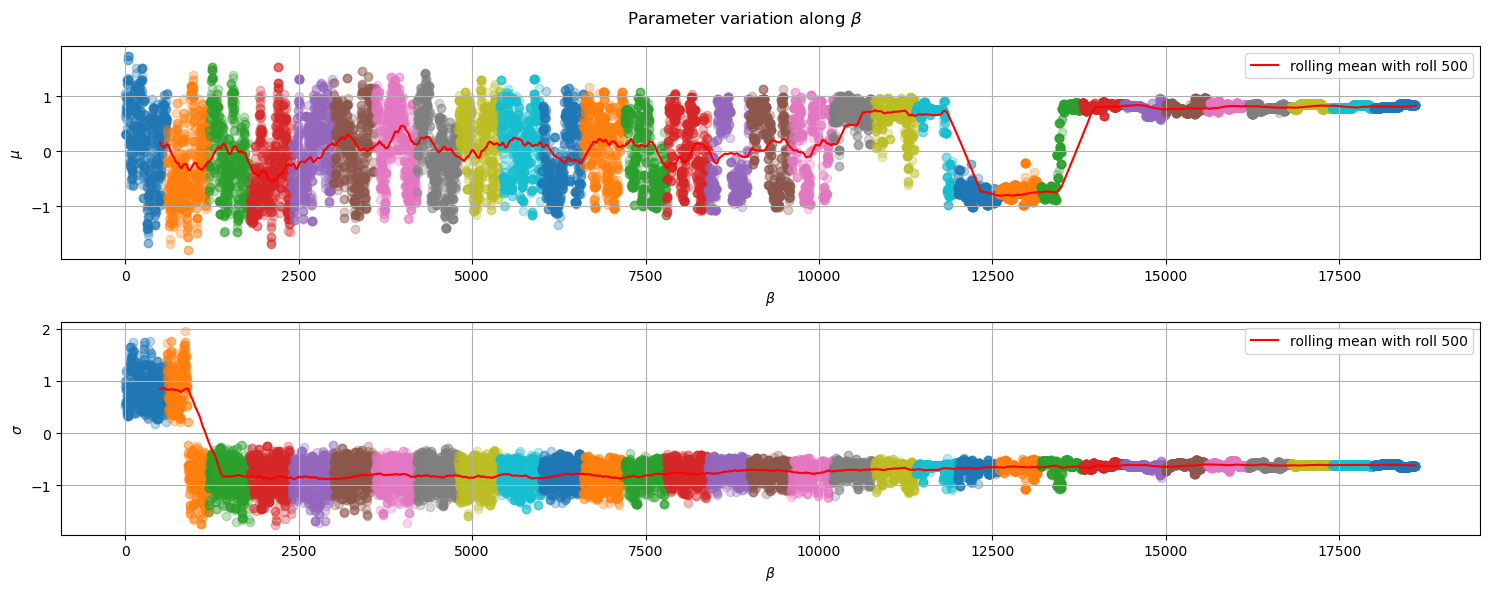

In [20]:
fig, ax = plt.subplots(2,1, figsize=(15,6))
fig.suptitle(r'Parameter variation along $\beta$')

window_size=500

for T in df.TEMP.unique():
    dft=df.loc[df.TEMP==T]
    ax[0].scatter(dft.index, dft['MU'], alpha=0.3)
    ax[1].scatter(dft.index, dft.SIGMA, alpha=0.3)

# ax[0].scatter(df.index, df['MU'], alpha=0.3)
ax[0].plot(df.index, df.MU.rolling(window_size).mean(), c='r', label=f'rolling mean with roll {window_size}')
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel(r'$\mu$')
ax[0].grid()
print("mu=",dflast['MU'][dflast.index[-1]])

# ax[1].scatter(df.index, df.SIGMA, alpha=0.3)
ax[1].plot(df.index, df['SIGMA'].rolling(window_size).mean(), c='r', label=f'rolling mean with roll {window_size}')
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel(r'$\sigma$')
ax[1].grid()

print('sigma = ', dflast['SIGMA'][dflast.index[-1]])

ax[0].legend()
ax[1].legend()
plt.tight_layout()

Finally below there is a picture of the $|\psi(x)|^2$ corresponding to the final value of the annealing process.

In [23]:
final_wf=pd.read_csv('CODE/OUTPUT/config2/final_wf.dat', skiprows=1)

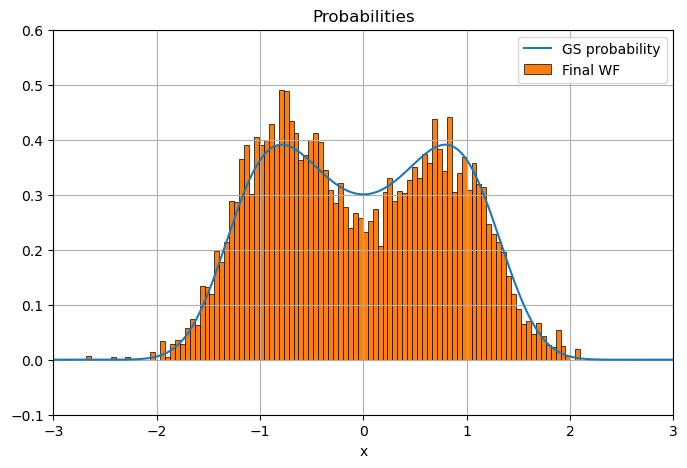

In [ ]:
# Plot a few things
plt.figure(figsize=(8,5))
scale = 0.3
plt.plot(x,(psi[0])**2, label='GS probability')
plt.hist(final_wf.pos, bins=100, density=True, linewidth=0.5, edgecolor="black", label='Final WF')
plt.title("Probabilities")
plt.xlabel("x")
plt.grid(True)
plt.xlim((-3,3))
plt.ylim((-0.1,0.6))
plt.legend()
plt.show()

# APPENDIX

### INPUT FILE STRUCTURE

### Example

```text
INITIAL_POS            0.0
MU                     1.0
SIGMA                  1.0
DELTA                  1.0
NBLOCKS                300
NSTEPS                 500
EQSTEPS                200
TEMP                   4.0
ANNEALSTEP_DIST        UNIFORM      1.0
ANNEAL_NSTEPS          600
COOLING_SCHEDULE       RATE_BETA         1.2
MAX_BETA               50
ENDINPUT
```
#### Arguments

- `INITIAL_POS     <x0:float>` 

    starting position to compute the energy using MC

- `MU  <mu:float>` 

    initial value of mu 

- `SIGMA <sigma:float>` 

    initial value of sigma

- `ANNEALSTEP_DIST  <distribution>  <distribution_width:float>`

    mu & sigma distribution to perform an annealing move 
    ```text
        Possible distribution:
        - "gauss" or  "GAUSS"
        - "uniform" or "UNIFORM"
    ```

- `TEMP <temp:float>`

    Initial temperature value

- `DELTA <delta:float>`
    width of MC step distribution used in energy calculation

- `NBLOCKS <nblocks:int>`
    number of blocks to perform the MC calculation of energy

- `NSTEPS <nsteps:int>`
    number of steps to perform the MC calculation of energy

- `ANNEAL_NSTEPS <nsteps:int>`
    number of steps per temperature value to perform the annealing 

- `EQSTEPS <nsteps:int>`
    equilibration steps to perform before computing the energy value
            
- `COOLING_SCHEDULE <annealing_schedule:string> <param:float>`

    Method to decrease temperature / increase beta
    ```text
        Possible schedules:        
            - ("step" || "STEP") -> param: step to decrease temperature

            - ("rate" || "RATE")  -> param: decrease factor

            - ("step_beta" || "STEP_BETA") -> step to increase beta

            - ("rate_beta" || "RATE_BETA") -> rate to increase beta
            
    ```

- `MIN_TEMP <temp:float>` or `MAX_BETA <beta:float>`

    value of temperature /beta at which the annealing stop

- `EN_FILENAME  <flename:string>`

    default file to store energy values

- `OPT_FILENAME <filename:string>`

    file to store the annealing steps values

- `LOG_FILENAME <filename:string>`

    file of log


- `ENDINPUT`
